# Compute & Research/Innovation vs. AI Diffusion — Income-Controlled Tests

**Sources:** Oxford GARI 2025 (195 countries), WIPO GII 2025 (139 economies), 
World Bank GDP per capita PPP. Merged on ISO3 country codes throughout — more 
robust than name-matching, since GII already carries ISO3 natively.

**Purpose:** Test whether compute capacity and research/innovation capacity 
predict AI diffusion *independently* of income, not just as another proxy for 
wealth. If they do, that's the citable basis for prioritizing investment in 
both — the point isn't whether Nepal is an income-adjusted anomaly, it's 
whether closing these specific gaps would move AI adoption beyond what income 
alone allows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

In [3]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../outputs/figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 11, "font.family": "sans-serif",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": "#333333", "axes.grid": True, "grid.alpha": 0.25,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})
sns.set_style("whitegrid")

In [4]:
def partial_corr(x, y, z):
    """Partial correlation of x,y controlling for z."""
    rxy, _ = stats.pearsonr(x, y)
    rxz, _ = stats.pearsonr(x, z)
    ryz, _ = stats.pearsonr(y, z)
    return (rxy - rxz * ryz) / np.sqrt((1 - rxz**2) * (1 - ryz**2))


In [5]:
def variance_explained(y, log_gdp, extra_var):
    """R² from income alone vs income+extra_var, and the marginal gain."""
    X1 = np.column_stack([np.ones(len(y)), log_gdp])
    X2 = np.column_stack([np.ones(len(y)), log_gdp, extra_var])
    b1, *_ = np.linalg.lstsq(X1, y, rcond=None)
    b2, *_ = np.linalg.lstsq(X2, y, rcond=None)
    r2_income = 1 - np.sum((y - X1 @ b1)**2) / np.sum((y - y.mean())**2)
    r2_both = 1 - np.sum((y - X2 @ b2)**2) / np.sum((y - y.mean())**2)
    return r2_income, r2_both, r2_both - r2_income

In [6]:
## 1. Load and merge — Oxford + World Bank GDP + GII, all on ISO3

OXFORD_FILE = RAW_DIR / "2025GovernmentAIReadinessIndexdata.xlsx"
GDP_FILE = next(RAW_DIR.glob("API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_*.csv"))
GDP_META_FILE = next(RAW_DIR.glob("Metadata_Country_API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_*.csv"))
GII_FILE = RAW_DIR / "wipo-pub-2000-2025-gii-tech1.xlsx"


In [7]:
# --- Oxford ---
xl = pd.ExcelFile(OXFORD_FILE)
oxford = xl.parse("Dimensions-Pillars", header=1)
oxford = oxford.drop(columns=[c for c in oxford.columns if "Unnamed" in str(c)])
oxford = oxford.dropna(subset=["Country"]).reset_index(drop=True)

In [8]:
# --- World Bank GDP (real countries only, latest available year per country) ---
wb = pd.read_csv(GDP_FILE, skiprows=4)
wb_meta = pd.read_csv(GDP_META_FILE)
real_codes = set(wb_meta.loc[wb_meta["Region"].notna(), "Country Code"])
wb = wb[wb["Country Code"].isin(real_codes)]
year_cols = [c for c in wb.columns if c.isdigit()]

def latest_value(row):
    for y in sorted(year_cols, reverse=True):
        if pd.notna(row[y]):
            return row[y]
    return np.nan

wb["gdp"] = wb.apply(latest_value, axis=1)
wb_clean = wb[["Country Name", "Country Code", "gdp"]].dropna(subset=["gdp"])

NAME_ALIASES = {
    "United States of America": "United States", "Russia": "Russian Federation",
    "South Korea": "Korea, Rep.", "Republic of Korea": "Korea, Rep.",
    "Vietnam": "Viet Nam", "Turkey": "Turkiye", "Türkiye": "Turkiye",
    "North Korea": "Korea, Dem. People's Rep.", "Egypt": "Egypt, Arab Rep.",
    "Iran": "Iran, Islamic Rep.", "Iran (Islamic Republic of)": "Iran, Islamic Rep.",
    "Syria": "Syrian Arab Republic", "Laos": "Lao PDR",
    "Lao People's Democratic Republic": "Lao PDR", "Congo": "Congo, Rep.",
    "Ivory Coast": "Cote d'Ivoire", "Côte D'Ivoire": "Cote d'Ivoire",
    "Slovakia": "Slovak Republic", "Brunei": "Brunei Darussalam",
    "Kyrgyzstan": "Kyrgyz Republic", "Gambia": "Gambia, The",
    "Gambia (Republic of The)": "Gambia, The", "Yemen": "Yemen, Rep.",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "United Republic of Tanzania": "Tanzania", "Republic of Moldova": "Moldova",
    "Bolivia (Plurinational State of)": "Bolivia", "Micronesia (Federated States of)": "Micronesia, Fed. Sts.",
}
oxford["match_name"] = oxford["Country"].replace(NAME_ALIASES)
m = oxford.merge(wb_clean, left_on="match_name", right_on="Country Name", how="left")
m = m.rename(columns={"Country Code": "ISO3"})

# --- GII, merged on ISO3 directly (no name-matching needed here) ---
gii_data = pd.read_excel(GII_FILE, sheet_name="Data")
gii_pivot = gii_data[gii_data.NUM.isin(["IN.2", "OUT.6"])].pivot(
    index="ISO3", columns="NUM", values="SCORE"
).rename(columns={"IN.2": "Human_Capital_Research", "OUT.6": "Knowledge_Tech_Output"})

full = m.merge(gii_pivot, on="ISO3", how="left")
full["log_gdp"] = np.log(full["gdp"])

print(f"Full merge: {full['gdp'].notna().sum()} with GDP, "
      f"{full.dropna(subset=['gdp','Human_Capital_Research']).shape[0]} with GDP+GII")
full[full.Country == "Nepal"][["Country", "ISO3", "gdp", "Compute capacity", "Human_Capital_Research", "AI technology diffusion"]]

Full merge: 180 with GDP, 137 with GDP+GII


,Country,ISO3,gdp,Compute capacity,Human_Capital_Research,AI technology diffusion
120,Nepal,NPL,6175.158972,6.9,13.91502,35.55


## 2. Extended comparison table — more countries, both dimensions

Major AI-adopter economies plus South Asia, absolute scores side by side.

In [10]:
!pip install tabulate

     ---------------------------------------- 0.0/40.8 kB ? eta -:--:--
     -------------------------------------- 40.8/40.8 kB 954.5 kB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
COMPARISON_COUNTRIES = [
    "Nepal", "China", "India", "United States of America", "United Kingdom of Great Britain and Northern Ireland",
    "Singapore", "Israel", "Republic of Korea", "Japan", "Germany",
    "Bangladesh", "Pakistan", "Sri Lanka", "Bhutan",
]

comp_table = full[full.Country.isin(COMPARISON_COUNTRIES)][
    ["Country", "gdp", "Compute capacity", "Human_Capital_Research", "Knowledge_Tech_Output", "AI technology diffusion", "Development & Diffusion"]
].sort_values("Compute capacity", ascending=False).reset_index(drop=True)

comp_table.to_csv(PROCESSED_DIR / "compute_research_diffusion_comparison.csv", index=False)
with open(PROCESSED_DIR / "compute_research_diffusion_comparison.md", "w") as f:
    f.write(comp_table.to_markdown(index=False))
comp_table

,Country,gdp,Compute capacity,Human_Capital_Research,Knowledge_Tech_Output,AI technology diffusion,Development & Diffusion
0,United States of America,90026.516301,90.92,55.768088,60.008974,85.96,88.16
1,China,29333.331105,80.66,51.959800,60.704520,77.74,74.67
2,Germany,75406.688811,56.98,61.035831,49.642733,74.10,66.24
3,Japan,55421.879753,50.49,53.497424,48.236801,71.00,66.13
4,United Kingdom of Great Britain and Northern I...,64606.495507,50.34,59.441877,55.958928,75.90,68.46
5,India,11747.916044,48.50,34.729731,37.812091,61.15,54.85
6,Singapore,163353.990260,41.99,63.310512,53.111464,69.59,64.15
7,Republic of Korea,63124.915218,40.81,66.991373,51.845094,82.00,65.88
8,Israel,59716.973539,21.14,52.312876,55.406377,86.51,64.66
9,Pakistan,6573.416134,9.99,15.801092,20.579317,48.02,36.95


## 3. Income-controlled test — Compute Capacity vs. AI Technology Diffusion

In [12]:
sub = full.dropna(subset=["Compute capacity", "AI technology diffusion", "log_gdp"])

r_raw, p_raw = stats.pearsonr(sub["Compute capacity"], sub["AI technology diffusion"])
pc_compute = partial_corr(sub["Compute capacity"], sub["AI technology diffusion"], sub["log_gdp"])
r2_income, r2_both, gain = variance_explained(
    sub["AI technology diffusion"].values, sub["log_gdp"].values, sub["Compute capacity"].values
)

print("=== Compute Capacity → AI Technology Diffusion ===")
print(f"n = {len(sub)}")
print(f"Raw correlation:              r={r_raw:.3f}, p={p_raw:.2e}")
print(f"Partial correlation (income controlled): r={pc_compute:.3f}")
print(f"R² from income alone:         {r2_income:.3f}")
print(f"R² from income + compute:     {r2_both:.3f}")
print(f"Additional variance from compute, beyond income: {gain:.3f} ({gain*100:.1f} pts)")

=== Compute Capacity → AI Technology Diffusion ===
n = 180
Raw correlation:              r=0.705, p=2.10e-28
Partial correlation (income controlled): r=0.575
R² from income alone:         0.435
R² from income + compute:     0.622
Additional variance from compute, beyond income: 0.187 (18.7 pts)


## 4. Income-controlled test — Human Capital & Research vs. AI Technology Diffusion

Same logic, applied to the research/innovation dimension.

In [13]:
sub2 = full.dropna(subset=["Human_Capital_Research", "AI technology diffusion", "log_gdp"])

r_raw2, p_raw2 = stats.pearsonr(sub2["Human_Capital_Research"], sub2["AI technology diffusion"])
pc_research = partial_corr(sub2["Human_Capital_Research"], sub2["AI technology diffusion"], sub2["log_gdp"])
r2_income2, r2_both2, gain2 = variance_explained(
    sub2["AI technology diffusion"].values, sub2["log_gdp"].values, sub2["Human_Capital_Research"].values
)

print("=== Human Capital & Research (GII) → AI Technology Diffusion ===")
print(f"n = {len(sub2)}")
print(f"Raw correlation:              r={r_raw2:.3f}, p={p_raw2:.2e}")
print(f"Partial correlation (income controlled): r={pc_research:.3f}")
print(f"R² from income alone:         {r2_income2:.3f}")
print(f"R² from income + research:    {r2_both2:.3f}")
print(f"Additional variance from research, beyond income: {gain2:.3f} ({gain2*100:.1f} pts)")

# Save both test results together
results = pd.DataFrame([
    {"Predictor": "Compute Capacity", "n": len(sub), "raw_r": r_raw, "partial_r_income_controlled": pc_compute,
     "R2_income_only": r2_income, "R2_income_plus_predictor": r2_both, "marginal_gain": gain},
    {"Predictor": "Human Capital & Research", "n": len(sub2), "raw_r": r_raw2, "partial_r_income_controlled": pc_research,
     "R2_income_only": r2_income2, "R2_income_plus_predictor": r2_both2, "marginal_gain": gain2},
])
results.to_csv(PROCESSED_DIR / "income_controlled_diffusion_tests.csv", index=False)
with open(PROCESSED_DIR / "income_controlled_diffusion_tests.md", "w") as f:
    f.write(results.to_markdown(index=False))
results

=== Human Capital & Research (GII) → AI Technology Diffusion ===
n = 137
Raw correlation:              r=0.737, p=1.07e-24
Partial correlation (income controlled): r=0.477
R² from income alone:         0.419
R² from income + research:    0.551
Additional variance from research, beyond income: 0.132 (13.2 pts)


,Predictor,n,raw_r,partial_r_income_controlled,R2_income_only,R2_income_plus_predictor,marginal_gain
0,Compute Capacity,180,0.705383,0.575173,0.434787,0.621773,0.186986
1,Human Capital & Research,137,0.736686,0.476571,0.419101,0.551035,0.131934


## 5. Figure — scatter, Compute vs. Diffusion, income-controlled residual framing

Two panels: raw relationship, and the same relationship after removing what 
income alone predicts — Nepal, comparison countries, and the trend line shown 
in both.

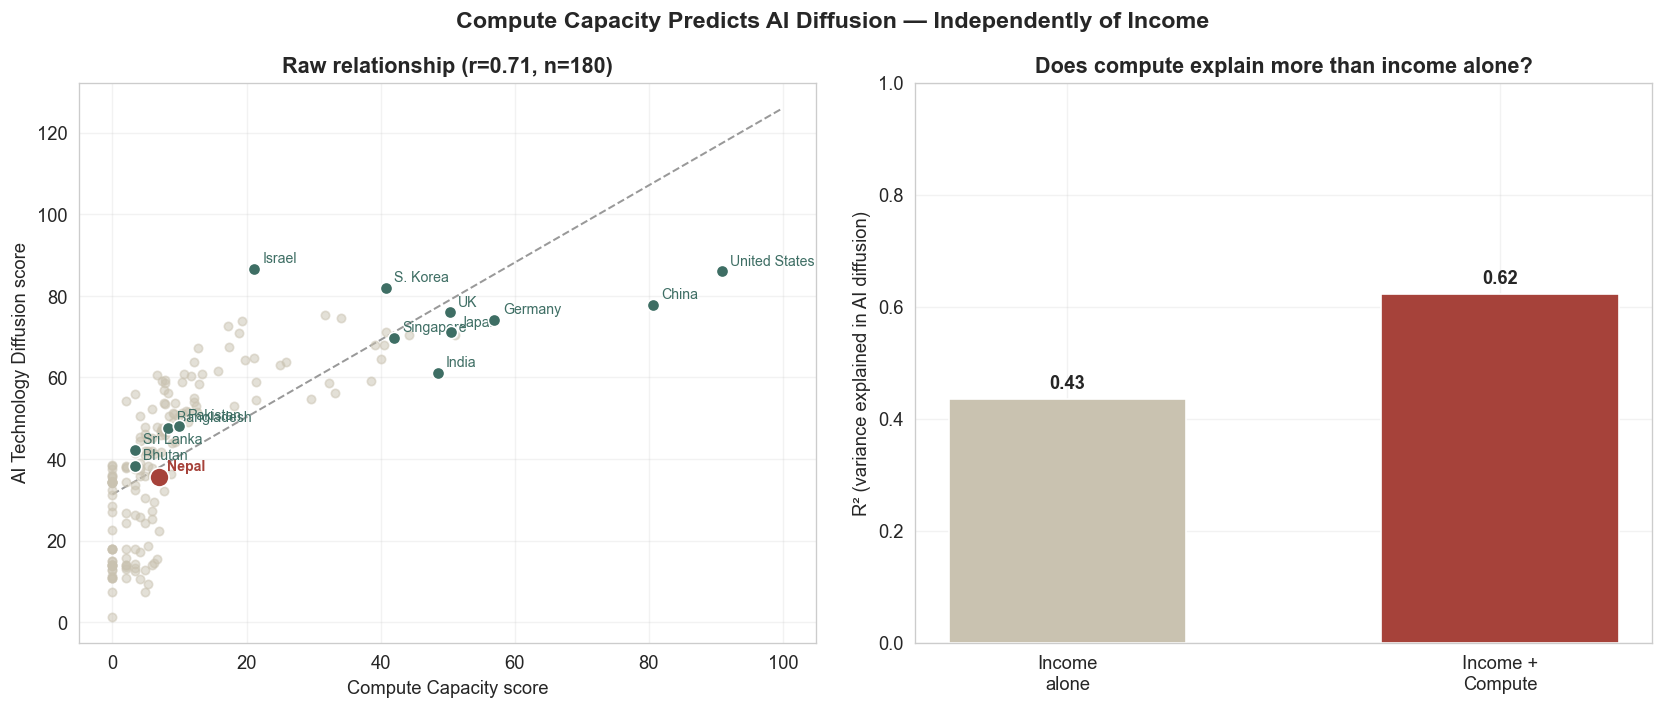

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: raw scatter
ax = axes[0]
ax.scatter(sub["Compute capacity"], sub["AI technology diffusion"], s=25, color="#c9c2b0", alpha=0.5, zorder=2)
slope, intercept, *_ = stats.linregress(sub["Compute capacity"], sub["AI technology diffusion"])
xline = np.linspace(0, 100, 50)
ax.plot(xline, slope*xline+intercept, color="#999999", linestyle="--", linewidth=1.2, zorder=1)

for c in COMPARISON_COUNTRIES:
    row = full[full.Country == c]
    if len(row) == 0 or row["Compute capacity"].isna().iloc[0]:
        continue
    row = row.iloc[0]
    color = "#A6423A" if c == "Nepal" else "#3E6E64"
    size = 130 if c == "Nepal" else 55
    ax.scatter(row["Compute capacity"], row["AI technology diffusion"], s=size, color=color, zorder=3, edgecolor="white")
    label = c.replace(" of America","").replace("United Kingdom of Great Britain and Northern Ireland","UK").replace("Republic of Korea","S. Korea")
    ax.annotate(label, (row["Compute capacity"], row["AI technology diffusion"]),
                xytext=(5,4), textcoords="offset points", fontsize=8.5,
                fontweight="bold" if c=="Nepal" else "normal", color=color)

ax.set_xlabel("Compute Capacity score")
ax.set_ylabel("AI Technology Diffusion score")
ax.set_title(f"Raw relationship (r={r_raw:.2f}, n={len(sub)})")

# Panel 2: R² comparison bar
ax2 = axes[1]
bars_x = ["Income\nalone", "Income +\nCompute"]
bars_y = [r2_income, r2_both]
ax2.bar(bars_x, bars_y, color=["#c9c2b0", "#A6423A"], width=0.55)
ax2.set_ylabel("R² (variance explained in AI diffusion)")
ax2.set_title("Does compute explain more than income alone?")
ax2.set_ylim(0, 1)
for i, v in enumerate(bars_y):
    ax2.text(i, v+0.02, f"{v:.2f}", ha="center", fontweight="bold")

fig.suptitle("Compute Capacity Predicts AI Diffusion — Independently of Income", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "compute_diffusion_income_controlled.png", bbox_inches="tight")
plt.show()

In [ ]:
!pip install statsmodels

In [15]:
import statsmodels.api as sm

sub3 = full.dropna(subset=["Compute capacity", "Human_Capital_Research", "AI technology diffusion", "log_gdp"])

X = sm.add_constant(sub3[["log_gdp", "Compute capacity", "Human_Capital_Research"]])
y = sub3["AI technology diffusion"]
joint_model = sm.OLS(y, X).fit()
print(joint_model.summary())

# Save as a clean, citable table
joint_results = pd.DataFrame({
    "Predictor": ["Income (log GDP per capita)", "Compute Capacity", "Human Capital & Research"],
    "Coefficient": joint_model.params[1:].values,
    "Std_Error": joint_model.bse[1:].values,
    "p_value": joint_model.pvalues[1:].values,
    "Significant_at_0.05": joint_model.pvalues[1:].values < 0.05,
})
joint_results.to_csv(PROCESSED_DIR / "joint_model_compute_research_income.csv", index=False)
with open(PROCESSED_DIR / "joint_model_compute_research_income.md", "w") as f:
    f.write(f"**R² = {joint_model.rsquared:.3f}, n = {len(sub3)}**\n\n")
    f.write(joint_results.to_markdown(index=False))

print(f"\nMulticollinearity check: correlation between Compute and Human Capital & Research: "
      f"r={sub3['Compute capacity'].corr(sub3['Human_Capital_Research']):.3f} — not severe enough to distort estimates")
joint_results

ModuleNotFoundError: No module named 'statsmodels'